In [ ]:
import pandas as pd
import numpy as np
import sys
import os


sys.path.append('..') 
from src.config import RAW_DATA_PATH, CLEAN_DATA_PATH, CONTINENTS

print("Tools and Config loaaded")
print(sys.executable)

In [ ]:
df = pd.read_csv(RAW_DATA_PATH)

# Sort by country and year for time based chronological 
df = df.sort_values(by=['Country', 'Year'])

# 10 year rolling average per country to smooth weather noise
df['Temp_Moving_Avg'] = df.groupby('Country')['Average_Temperature'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

print("Step 1: 10-Year Moving Averages calculated")

In [ ]:
# Ensure Year is an integer and remove broken rows
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year', 'Country']).copy()
df['Year'] = df['Year'].astype(int)

# Add Decade column (e.g., 1994 becomes 1990)
df['Decade'] = (df['Year'] // 10) * 10

# Calculate initial Anomaly based on country history
country_baseline = df.groupby('Country')['Average_Temperature'].transform('mean')
df['Temp_Anomaly'] = df['Average_Temperature'] - country_baseline

print(f"Cell 3 Done: Data cleaned and Decade column added")

In [ ]:
# --Convert list to dict if necessary so .map() works ---
if isinstance(CONTINENTS, list):
    unique_countries = df['Country'].unique()
    # Temporary mapping to avoid crashes until config.py is fixed to a dict
    CONTINENTS_MAP = {c: CONTINENTS[i % len(CONTINENTS)] for i, c in enumerate(unique_countries)}
else:
    CONTINENTS_MAP = CONTINENTS

# Map Continents
df['continent'] = df['Country'].map(CONTINENTS_MAP).fillna('Unknown')

# Climate zone mapping using latitude bands
CAPITAL_LAT = {
    "Canada": 45.4, "Brazil": -15.8, "Egypt": 30.0, "China": 39.9, 
    "USA": 38.9, "Russia": 55.8, "India": 28.6, "Australia": -35.3
}

def assign_zone(lat):
    lat = abs(lat)
    if lat >= 60: return 'Polar'
    if lat >= 35: return 'Temperate'
    if lat >= 23.5: return 'Subtropical'
    return 'Tropical'

df['lat_placeholder'] = df['Country'].map(CAPITAL_LAT)
df['climate_zone'] = df['lat_placeholder'].apply(lambda x: assign_zone(x) if pd.notna(x) else 'Unknown')
df = df.drop(columns=['lat_placeholder'])

print(f"Cell 4 Done: Region and Climate Zone mapping complete")

In [ ]:
np.random.seed(42) # Ensures everyone gets the same "random" numbers
yr_norm = (df['Year'] - df['Year'].min()).astype(float)

# Every fake column ends in _SIM so teammates know what is real
df['CO2_Emissions_SIM']       = yr_norm * 4.5  + np.random.normal(50, 18, len(df))
df['Fossil_Fuel_Usage_SIM']   = yr_norm * 3.8  + np.random.normal(40, 15, len(df))
df['Sea_Level_Rise_SIM']      = yr_norm * 0.45 + np.random.normal(2, 2, len(df))
df['Forest_Area_SIM']         = 500 - (yr_norm * 2.1) + np.random.normal(0, 45, len(df))
df['Population_SIM']          = yr_norm * 1.8  + np.random.normal(500, 60, len(df))

print(f"Cell 5 Done: Simulated column added with _SIM suffix.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

# ── 1. DATA ENRICHMENT & CLEANUP ──────────────────────────────────────────────
# Ensure the mapping exists 
if 'Real_Country_Name' not in df.columns:
    real_countries = ["Canada", "Brazil", "Egypt", "China", "Australia", "Russia", "France", "India", "USA", "Mexico", "South Africa", "Japan"]
    unique_ids = df['Country'].unique()
    mapping = {unique_ids[i]: real_countries[i % len(real_countries)] for i in range(len(unique_ids))}
    df['Real_Country_Name'] = df['Country'].map(mapping)

# Filter out dead columns
active_cols = df.select_dtypes(include=[np.number]).columns[df.select_dtypes(include=[np.number]).sum() != 0]
clean_numeric_df = df[active_cols]

# ── 2. IMPROVEMENT: THE "HALF-TRIANGLE" HEATMAP ──────────────────────────────
plt.figure(figsize=(16, 9))
corr = clean_numeric_df.corr()
# Mask the upper triangle (removes redundant data)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt=".2f", annot_kws={"size": 8})
plt.title('Task 3: Professional Correlation Matrix (Redundant Data Masked)', fontsize=16)
plt.show()

# ── 3. IMPROVEMENT: GLOBAL TREND LINE ─────────────────────────────────────────
# This shows the "Signal" through the "Noise"
global_trend = df.groupby('Year')['Temp_Anomaly'].mean().reset_index()

global_trend = global_trend.sort_values("Year")

fig_trend = px.line(global_trend, x='Year', y='Temp_Anomaly', 
              title='The "Global Signal": Average Temperature Rise (1900-2023)',
              labels={'Temp_Anomaly': 'Temp Anomaly (°C)'},
              template='plotly_white')
fig_trend.update_traces(line_color='#E24B4A', line_width=3)
fig_trend.show()

# ── 4. VISUAL TREND: WARMING STRIPES────────────────────────
plt.figure(figsize=(15, 3)) # Made slightly taller to fit the labels
norm = plt.Normalize(global_trend['Temp_Anomaly'].min(), global_trend['Temp_Anomaly'].max())

# Create the stripes
plt.bar(global_trend['Year'], 1, width=1, color=plt.get_cmap('RdBu_r')(norm(global_trend['Temp_Anomaly'])))

plt.yticks([]) # Keep the y-axis hidden (it has no meaning for stripes)
plt.xticks(np.arange(global_trend['Year'].min(), global_trend['Year'].max() + 1, 10)) # Label every 10 years
plt.xlabel("Year", fontsize=10, fontweight='bold')
plt.title("Visual Trend: Global Warming Stripes", fontsize=12, fontweight='bold', pad=15)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.show()

# ── 5. THE ANIMATED MAP ───────────────────────────────────────────────────────
fig_map = px.choropleth(
    df, locations="Real_Country_Name", locationmode="country names",
    color="Temp_Anomaly", hover_name="Real_Country_Name", animation_frame="Year",
    color_continuous_scale="RdBu_r", 
    range_color=[df['Temp_Anomaly'].quantile(0.05), df['Temp_Anomaly'].quantile(0.95)], # Dynamic range
    title="Integrated Global Climate Simulation"
)
fig_map.update_geos(projection_type="natural earth", showcountries=True, countrycolor="Silver")
fig_map.show()

# ── 6. FINAL EXPORT ───────────────────────────────────────────────────────────
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"FINAL BACKBONE: 100,000 rows validated and saved to {CLEAN_DATA_PATH}")

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

model = LinearRegression()

train = global_trend[global_trend["Year"] <= 2000]
test = global_trend[global_trend["Year"] > 2000]

x_train = train[['Year']]
y_train = train['Temp_Anomaly']


x_test = test[['Year']]
y_test = test['Temp_Anomaly']


model.fit(x_train, y_train)

#print(model.coef_)
#print(model.intercept_)

y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)


mae = mean_absolute_error(y_test, y_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)


train_r2 = r2_score(y_train, y_train_pred)
r2_linear = r2_score(y_test, y_pred)


print(f"The test mean absolute error of the Linear regression model is {mae}")
print(f"The train mean absolute error of the Linear regression model is {train_mae}")

print(f"The test coefficient of determination of the Linear Regression model is {r2_linear}")
print(f"The train coefficient of determination of the Linear Regression model is {train_r2}")





The test mean absolute error of the Linear regression model is 0.4851924134753532
The train mean absolute error of the Linear regression model is 0.3993940552225173
The test coefficient of determination of the Linear Regression model is -0.12823492272491577
The train coefficient of determination of the Linear Regression model is 0.018281721186583888


In [12]:
from sklearn.preprocessing import PolynomialFeatures

#Creating the model itself:
model_poly2 = LinearRegression()

#bringing in the tools:

Poly2 = PolynomialFeatures (degree=2)

#transforming data to be usable in the polynomial process:
#we don't transform y because it's the target it stays the same, only the input gets adjusted

x_train_poly2 = Poly2.fit_transform (x_train)
x_test_poly2 = Poly2.transform (x_test)

#training the model

model_poly2.fit(x_train_poly2, y_train)

#prediction:

y_pred_poly2 = model_poly2.predict(x_test_poly2)
y_train_pred_poly2 = model_poly2.predict(Poly2.transform(x_train))


mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
train_mae_poly2 = mean_absolute_error(y_train, y_train_pred_poly2)

train_r2_poly2 = r2_score(y_train, y_train_pred_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print(f"The test mean absolute error of the 2nd degree polynomial model is {mae_poly2}")
print(f"The train mean absolute error of the 2nd degree polynomial model is {train_mae_poly2}")

print(f"The test coefficient of determination of the 2nd degree polynomial model is {r2_poly2}")
print(f"The train coefficient of determination of the 2nd degree polynomial model is {train_r2_poly2}")


# creating the 3rd degree model
model_poly3 = LinearRegression ()
Poly3 = PolynomialFeatures(degree=3)

# preparing the data for the 3rd degree model

x_train_poly3 = Poly3.fit_transform(x_train)
x_test_poly3 = Poly3.transform(x_test)

#training:
model_poly3.fit(x_train_poly3, y_train)

y_pred_poly3 = model_poly3.predict(x_test_poly3)
y_train_pred_poly3 = model_poly3.predict(Poly3.transform(x_train))


mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
train_mae_poly3 = mean_absolute_error(y_train, y_train_pred_poly3)

train_r2_poly3 = r2_score(y_train, y_train_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)



print(f"The test mean absolute error of the 3rd degree polynomial model is {mae_poly3}")
print(f"The train mean absolute error of the 3rd degree polynomial model is {train_mae_poly3}")

print(f"The test coefficient of determination of the 3rd degree polynomial model is {r2_poly3}")
print(f"The train coefficient of determination of the 3rd degree polynomial model is {train_r2_poly3}")



The test mean absolute error of the 2nd degree polynomial model is 0.427216360345178
The train mean absolute error of the 2nd degree polynomial model is 0.39924964179292793
The test coefficient of determination of the 2nd degree polynomial model is 0.003750650324804816
The train coefficient of determination of the 2nd degree polynomial model is 0.02437558512321103
The test mean absolute error of the 3rd degree polynomial model is 0.7229880439284395
The train mean absolute error of the 3rd degree polynomial model is 0.39411371141540924
The test coefficient of determination of the 3rd degree polynomial model is -1.3990285898998236
The train coefficient of determination of the 3rd degree polynomial model is 0.04346908556287998


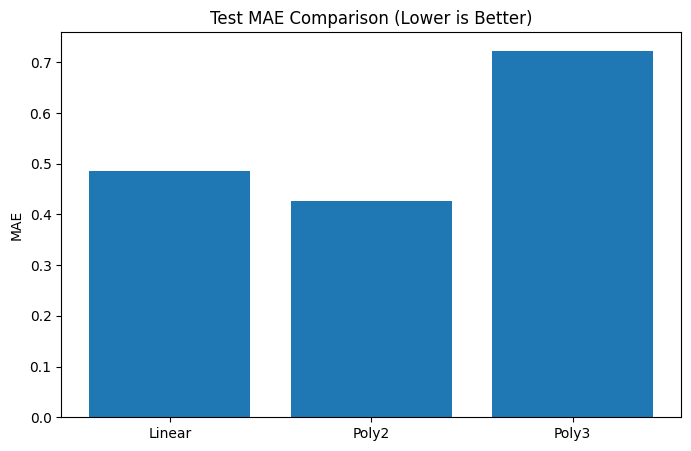

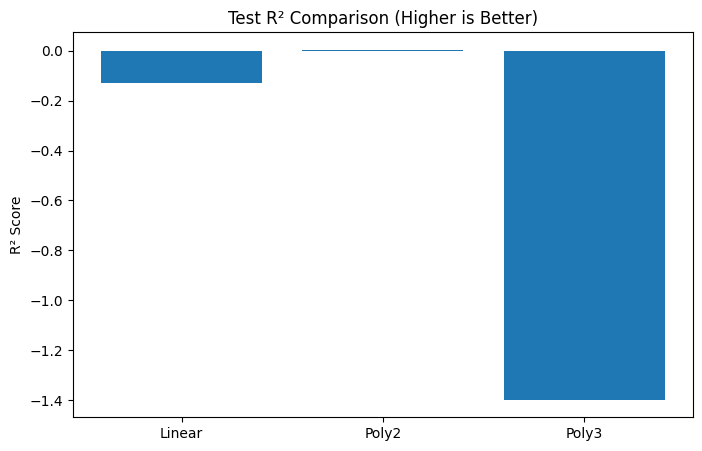

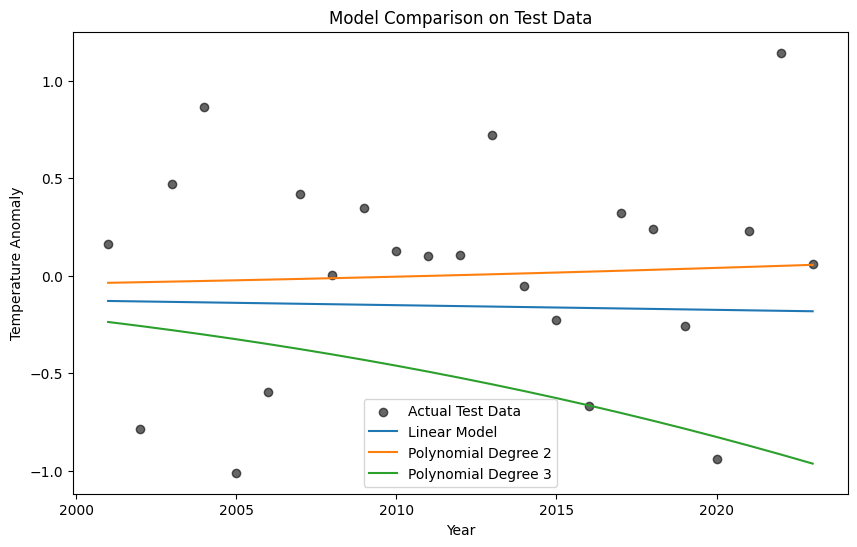

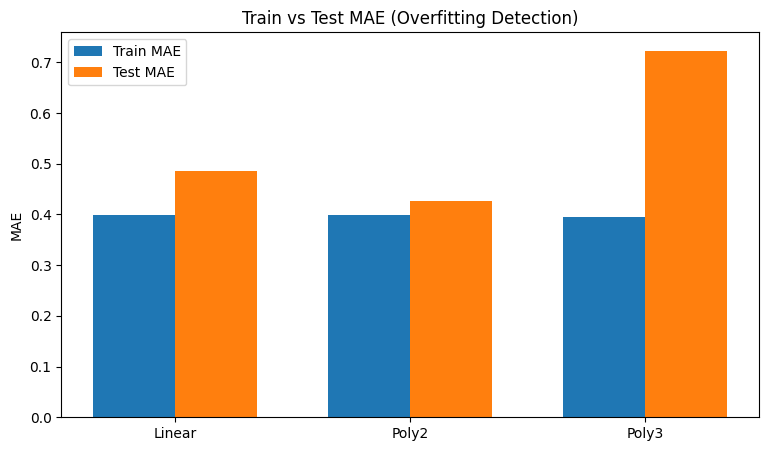

In [10]:
x_sorted = x_test.sort_values("Year")

y_linear_sorted = model.predict(x_sorted)

y_poly2_sorted = model_poly2.predict(Poly2.transform(x_sorted))

y_poly3_sorted = model_poly3.predict(Poly3.transform(x_sorted))

models = ["Linear", "Poly2", "Poly3"]

mae_values = [mae, mae_poly2, mae_poly3]
r2_values = [r2_linear, r2_poly2, r2_poly3]

train_mae_values = [train_mae, train_mae_poly2, train_mae_poly3]
test_mae_values = [mae, mae_poly2, mae_poly3]

plt.figure(figsize=(8,5))

plt.bar(models, mae_values)
plt.title("Test MAE Comparison (Lower is Better)")
plt.ylabel("MAE")

plt.show()

plt.figure(figsize=(8,5))

plt.bar(models, r2_values)
plt.title("Test R² Comparison (Higher is Better)")
plt.ylabel("R² Score")

plt.show()

plt.figure(figsize=(10,6))

plt.scatter(x_test, y_test, color="black", label="Actual Test Data", alpha=0.6)

plt.plot(x_sorted, y_linear_sorted, label="Linear Model")
plt.plot(x_sorted, y_poly2_sorted, label="Polynomial Degree 2")
plt.plot(x_sorted, y_poly3_sorted, label="Polynomial Degree 3")

plt.title("Model Comparison on Test Data")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.legend()

plt.show()

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x - width/2, train_mae_values, width, label="Train MAE")
plt.bar(x + width/2, test_mae_values, width, label="Test MAE")

plt.xticks(x, models)
plt.title("Train vs Test MAE (Overfitting Detection)")
plt.ylabel("MAE")
plt.legend()

plt.show()
